,Experimental data,PS-MPs (%),RBCs (106 mm-3),WBCs (103 mm-3),PLT,Hb (g/100 ml),MCHC (%),MCH (pg),MCV (fl.),PCV (%)
0,TD-I,0.0,1.94,2.26,310.75,8.91,27.11,45.87,169.23,32.88
1,TD-II,0.5,1.76,2.34,308.44,8.43,26.63,47.92,179.94,31.67
2,TD-III,1.0,1.67,2.47,307.20,8.25,26.49,49.51,186.91,31.15
3,TD-IV,1.5,1.56,2.56,306.81,8.17,26.47,52.25,197.43,30.86
4,TD-V,2.0,1.41,2.65,305.29,7.72,25.99,54.91,211.27,29.72


,Experimental data (Feed),PS-MPs (Feed),GE (%) (Feed),CF (%) (Feed),CP (%) (Feed)
0,TD-I,0.0,3.37,8.06,30.62
1,TD-II,0.5,3.41,8.04,30.76
2,TD-III,1.0,3.46,8.05,30.84
3,TD-IV,1.5,3.41,8.03,30.68
4,TD-V,2.0,3.46,8.05,30.88


Microplastics in Labeo rohita dataset


,mean,median,std
PS-MPs_numeric,1.250000,1.250,0.935414
RBCs (106 mm-3),1.596667,1.615,0.250333
Hb (g/100 ml),8.131667,8.210,0.557653
WBCs (103 mm-3),2.525000,2.515,0.220613


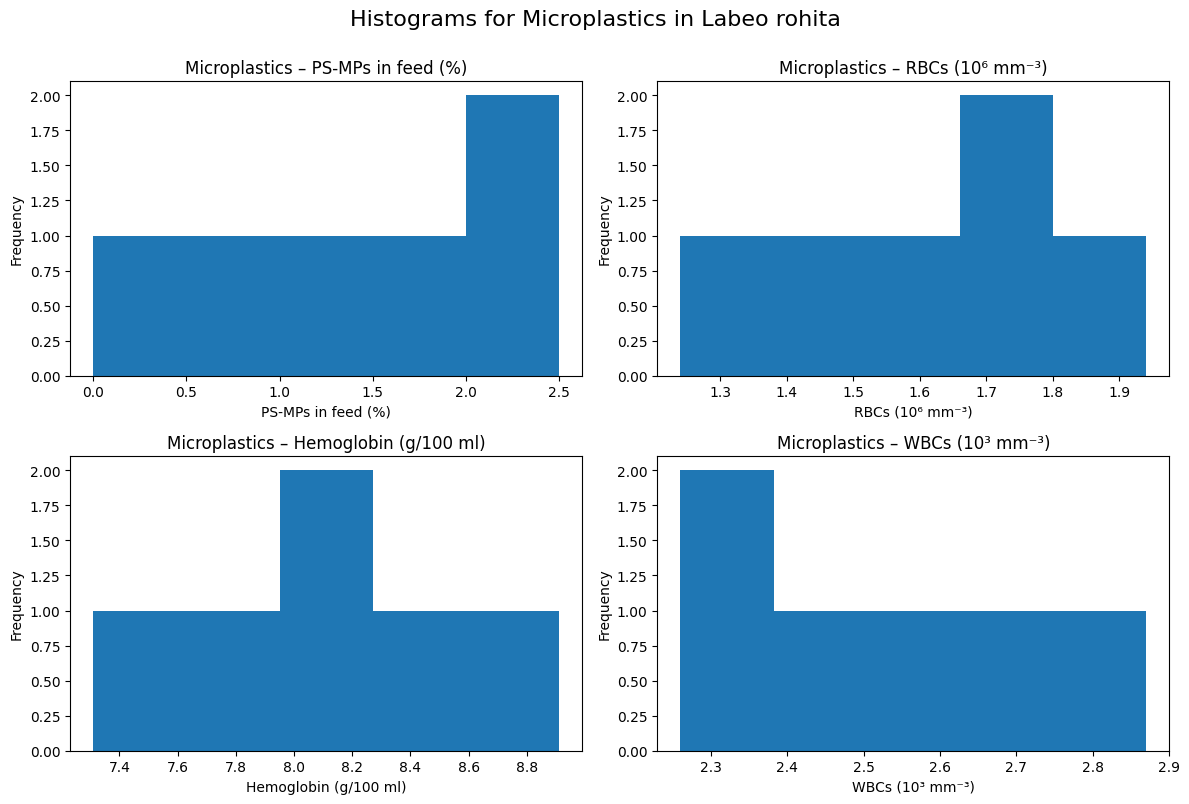

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

# Make plots appear inside the notebook
%matplotlib inline

#file paths for the Microplastics and feed
micro_path = "Microplastics Course Project table 1.csv"
feed_path  = "Feed Course Project.csv"

#reading the data
micro_df = pd.read_csv(micro_path)
feed_df  = pd.read_csv(feed_path)

display(micro_df.head())
display(feed_df.head())


feed = feed_df.copy()

#making the percent values from csv into floats
feed["PS-MPs_numeric"] = (
    feed["PS-MPs (Feed)"]
    .astype(str)
    .str.replace("%", "", regex=False)
)
feed["PS-MPs_numeric"] = pd.to_numeric(feed["PS-MPs_numeric"], errors="coerce")

#merging tables
micro = micro_df.copy()

micro_merged = micro.merge(
    feed[["Experimental data (Feed)", "PS-MPs_numeric"]],
    left_on="Experimental data",
    right_on="Experimental data (Feed)",
    how="left"
)

#Reducing the columns to only ones used in my hypothesis (PS-MPs, RBCs, HBs, WBCs)
relevant_cols = [
    "PS-MPs_numeric",       
    "RBCs (106 mm-3)",       
    "Hb (g/100 ml)",          
    "WBCs (103 mm-3)"         
]

analysis_df = micro_merged[relevant_cols].copy()

#Summary statistics of mean, median, and standard deviation
stats = analysis_df.agg(["mean", "median", "std"]).T

print("Microplastics in Labeo rohita dataset")
display(stats)

def plot_histograms(df, dataset_name, column_labels=None, bins=5):
   
    cols = df.columns.tolist()
    n = len(cols)
    n_cols = 2
    n_rows = (n + n_cols - 1) // n_cols  # ceiling division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        ax = axes[i]
        ax.hist(df[col].dropna(), bins=bins)
        label = column_labels.get(col, col) if column_labels else col
        ax.set_title(f"{dataset_name} – {label}")
        ax.set_xlabel(label)
        ax.set_ylabel("Frequency")

    # hide any unused subplot axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Histograms for Microplastics in Labeo rohita", y=1.00, fontsize=16)
    plt.tight_layout()
    plt.show()


nice_labels = {
    "PS-MPs_numeric": "PS-MPs in feed (%)",
    "RBCs (106 mm-3)": "RBCs (10⁶ mm⁻³)",
    "Hb (g/100 ml)": "Hemoglobin (g/100 ml)",
    "WBCs (103 mm-3)": "WBCs (10³ mm⁻³)"
}

plot_histograms(analysis_df, "Microplastics", column_labels=nice_labels)

Pearson correlation table


,PS-MPs_numeric,RBCs (106 mm-3),Hb (g/100 ml),WBCs (103 mm-3)
PS-MPs_numeric,1.000000,-0.995024,-0.978651,0.986120
RBCs (106 mm-3),-0.995024,1.000000,0.993035,-0.988290
Hb (g/100 ml),-0.978651,0.993035,1.000000,-0.977929
WBCs (103 mm-3),0.986120,-0.988290,-0.977929,1.000000


Spearman correlation table


,PS-MPs_numeric,RBCs (106 mm-3),Hb (g/100 ml),WBCs (103 mm-3)
PS-MPs_numeric,1.0,-1.0,-1.0,1.0
RBCs (106 mm-3),-1.0,1.0,1.0,-1.0
Hb (g/100 ml),-1.0,1.0,1.0,-1.0
WBCs (103 mm-3),1.0,-1.0,-1.0,1.0



PS-MPs vs RBCs (106 mm-3)
  Pearson r : -0.9950240943455929
  Spearman ρ: -1.0

PS-MPs vs Hb (g/100 ml)
  Pearson r : -0.9786509406542362
  Spearman ρ: -1.0

PS-MPs vs WBCs (103 mm-3)
  Pearson r : 0.9861198794093852
  Spearman ρ: 1.0


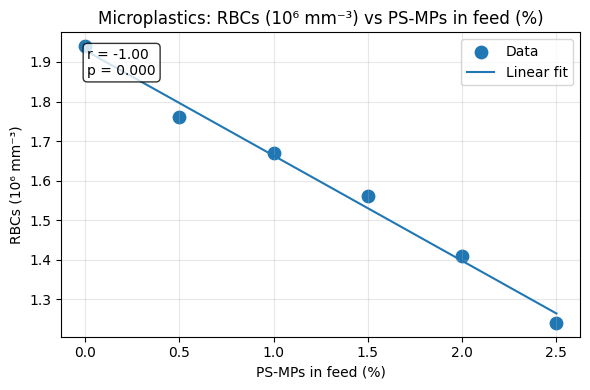

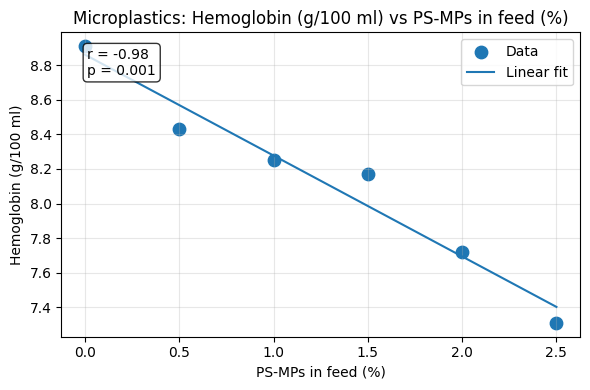

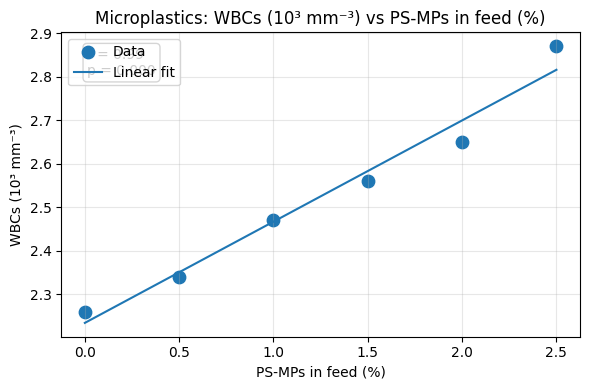

Linear regression summary


,Response,slope,intercept,r_value,r_squared,p_value,std_err
0,RBCs,-0.266286,1.929524,-0.995024,0.990073,0.000037,0.013332
1,Hb,-0.583429,8.860952,-0.978651,0.957758,0.000679,0.061264
2,WBCs,0.232571,2.234286,0.986120,0.972432,0.000288,0.019579


In [65]:
import numpy as np
from scipy.stats import linregress
#Pearson correlation
pearson_corr = analysis_df.corr(method="pearson")
print("Pearson correlation table")
display(pearson_corr)

#Spearman correlation
spearman_corr = analysis_df.corr(method="spearman")
print("Spearman correlation table")
display(spearman_corr)

#If you specifically want PS-MPs vs each blood variable:
for col in ["RBCs (106 mm-3)", "Hb (g/100 ml)", "WBCs (103 mm-3)"]:
    print(f"\nPS-MPs vs {col}")
    print("  Pearson r :", pearson_corr.loc["PS-MPs_numeric", col])
    print("  Spearman ρ:", spearman_corr.loc["PS-MPs_numeric", col])
    
from scipy.stats import linregress

def regress_and_plot(x, y, x_label, y_label, title_prefix="Microplastics"):

    mask = (~x.isna()) & (~y.isna())
    x_clean = x[mask]
    y_clean = y[mask]

    result = linregress(x_clean, y_clean)

    #boom, regression line
    x_vals = np.linspace(x_clean.min(), x_clean.max(), 100)
    y_pred = result.slope * x_vals + result.intercept

    plt.figure(figsize=(6, 4))
    plt.scatter(x_clean, y_clean, s=80, label="Data")
    plt.plot(x_vals, y_pred, label="Linear fit")

    plt.title(f"{title_prefix}: {y_label} vs {x_label}")
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    # annotate with r and p
    text = f"r = {result.rvalue:.2f}\np = {result.pvalue:.3f}"
    plt.annotate(text, xy=(0.05, 0.95), xycoords="axes fraction",
                 ha="left", va="top",
                 bbox=dict(boxstyle="round", fc="white", alpha=0.8))

    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return result


#Run regressions for each key blood variable

x = analysis_df["PS-MPs_numeric"]

reg_results = {}

reg_results["RBCs"] = regress_and_plot(
    x,
    analysis_df["RBCs (106 mm-3)"],
    x_label="PS-MPs in feed (%)",
    y_label="RBCs (10⁶ mm⁻³)"
)

reg_results["Hb"] = regress_and_plot(
    x,
    analysis_df["Hb (g/100 ml)"],
    x_label="PS-MPs in feed (%)",
    y_label="Hemoglobin (g/100 ml)"
)

reg_results["WBCs"] = regress_and_plot(
    x,
    analysis_df["WBCs (103 mm-3)"],
    x_label="PS-MPs in feed (%)",
    y_label="WBCs (10³ mm⁻³)"
)
summary_rows = []
for name, res in reg_results.items():
    summary_rows.append({
        "Response": name,
        "slope": res.slope,
        "intercept": res.intercept,
        "r_value": res.rvalue,
        "r_squared": res.rvalue**2,
        "p_value": res.pvalue,
        "std_err": res.stderr
    })

reg_summary = pd.DataFrame(summary_rows)
print("Linear regression summary")
display(reg_summary)

Proportion of variance 


PC1    0.987785
PC2    0.008974
dtype: float64


Cumulative variance:


PC1    0.987785
PC2    0.996759
dtype: float64


PC1 & PC2


,PC1,PC2
RBCs (106 mm-3),-0.355125,0.034074
WBCs (103 mm-3),0.352202,-0.469049
PLT,-0.353799,-0.238366
Hb (g/100 ml),-0.354644,-0.269869
MCHC (%),-0.350419,-0.612933
MCH (pg),0.353047,-0.424022
MCV (fl.),0.354221,-0.289917
PCV (%),-0.354943,-0.098241


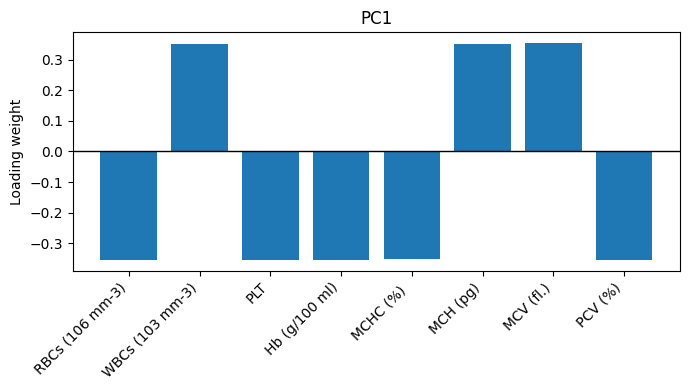

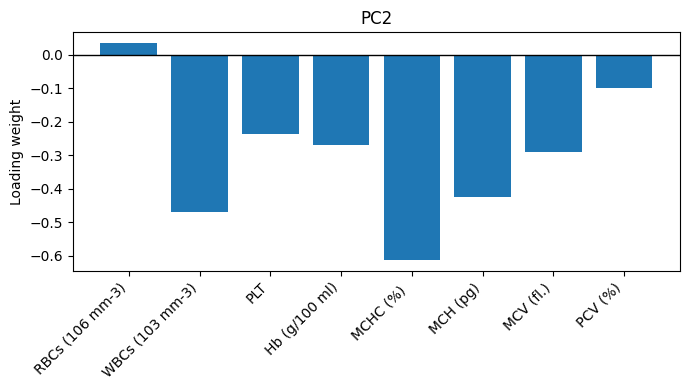

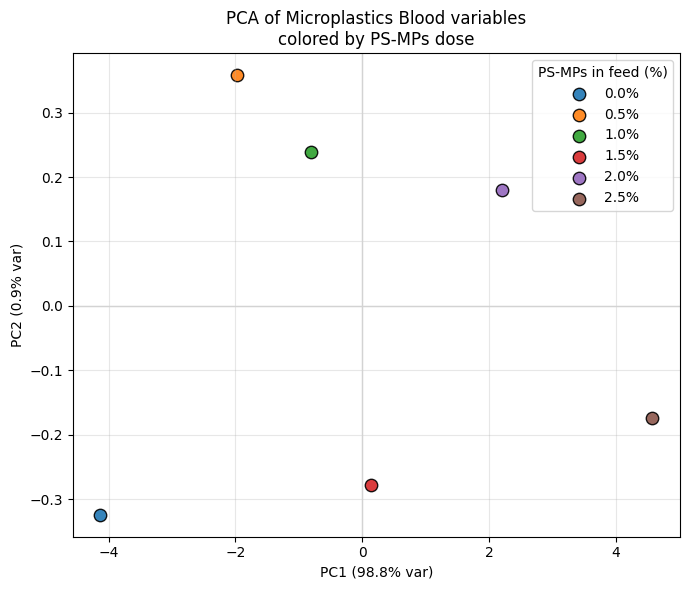

In [70]:
def run_pca(df, feature_cols, category_col, n_components=2):
    X = df[feature_cols].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    max_components = min(X_scaled.shape[0], X_scaled.shape[1])
    n_components = min(n_components, max_components)

    #PCA start
    pca = PCA(n_components=n_components)
    pcs = pca.fit_transform(X_scaled)
    pc_cols = [f"PC{i+1}" for i in range(n_components)]
    pc_scores = pd.DataFrame(pcs, columns=pc_cols)
    pc_scores[category_col] = df[category_col].values

    loadings = pd.DataFrame(
        pca.components_.T,
        index=feature_cols,
        columns=pc_cols
    )

    explained = pd.Series(
        pca.explained_variance_ratio_,
        index=pc_cols
    )

    return pca, pc_scores, loadings, explained


#Running PCA
pca, pc_scores, loadings, explained = run_pca(
    pca_df,
    feature_cols=hemo_features,
    category_col="PS-MPs_numeric",
    n_components=2      # PC1 & PC2 only
)

print("Proportion of variance ")
display(explained)
print("\nCumulative variance:")
display(explained.cumsum())

print("\nPC1 & PC2")
display(loadings[["PC1", "PC2"]])


def plot_loadings_bar(loadings, component):
    plt.figure(figsize=(7,4))
    plt.bar(loadings.index, loadings[component])
    plt.axhline(0, color="black", linewidth=1)
    plt.title(f"{component}")
    plt.ylabel("Loading weight")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

plot_loadings_bar(loadings, "PC1")
plot_loadings_bar(loadings, "PC2")


#PC1 vs PC2 scatter, colored by PS-MPs dose
pc_scores_plot = pc_scores.copy()
pc_scores_plot["Dose_label"] = pc_scores_plot["PS-MPs_numeric"].astype(str) + "%"

dose_levels = sorted(
    pc_scores_plot["Dose_label"].unique(),
    key=lambda s: float(s.replace("%", ""))
)

colors = ["tab:blue", "tab:orange", "tab:green",
          "tab:red", "tab:purple", "tab:brown"]

plt.figure(figsize=(7,6))
for d, c in zip(dose_levels, colors):
    subset = pc_scores_plot[pc_scores_plot["Dose_label"] == d]
    plt.scatter(
        subset["PC1"], subset["PC2"],
        label=d, s=80, edgecolor="black", alpha=0.9, color=c
    )

plt.axhline(0, color="lightgray", linewidth=1)
plt.axvline(0, color="lightgray", linewidth=1)

plt.xlabel(f"PC1 ({explained['PC1']*100:.1f}% var)")
plt.ylabel(f"PC2 ({explained['PC2']*100:.1f}% var)")
plt.title("PCA of Microplastics Blood variables\ncolored by PS-MPs dose")
plt.legend(title="PS-MPs in feed (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()